# Create population data figure

## Imports

In [1]:
from pathlib import Path
import re
import logging

import numpy as np
import pandas as pd
import pingouin
import matplotlib.pyplot as plt
from matplotlib.colors import CenteredNorm, Normalize
from matplotlib.cm import ScalarMappable

from gulp2p.preproc.tiff import Tiff
from gulp2p.preproc.experiment import Experiment, create_expt_df
from gulp2p.preproc import utils, imaging, behavior, trial as tr
from gulp2p.viz import plotting

from matplotlib import rcParams
rcParams['pdf.fonttype'] = 42
rcParams['svg.fonttype'] = "none"

### Logging config

In [2]:
log_level = logging.INFO    # log levels: DEBUG, INFO, WARNING, ERROR, CRITICAL
log_format = "{asctime} - {levelname} - {name} - [{filename} {funcName}() {lineno}] - {message}"
logging.basicConfig(format=log_format, level=log_level, style="{") 

logging.getLogger("gulp2p").setLevel(logging.DEBUG)
logger = logging.getLogger(__name__)

#### Outline:
- Select trials
  - Organize trials into expts
- Get mean bump profile
- Fit cosine to bump
- calculate r^2
- generate population plot with r^2

## Select Data

### Functions:

In [3]:
CELL_TYPES = ["DR015", "DR018", "DR019"]

GENETIC_TOOLS = ["iGluSnFR"]

### Create trial dataframe:

In [4]:
TIFF_FOLDER = Path(r"Z:\2PImaging\Kerstin\MIMS")

trial_df = tr.create_trial_df(TIFF_FOLDER, CELL_TYPES, GENETIC_TOOLS)

In [5]:
trial_df.head()

,path,date,line,cell_type,genetic_tool,fly,trial
0,Z:\2PImaging\Kerstin\MIMS\20231109\Fly1_8days_...,20231109,iGluSnFRxSS2232,iGluSnFR,SS2232,1,1
1,Z:\2PImaging\Kerstin\MIMS\20231109\Fly1_8days_...,20231109,iGluSnFRxSS2232,iGluSnFR,SS2232,1,2
2,Z:\2PImaging\Kerstin\MIMS\20231109\Fly1_8days_...,20231109,iGluSnFRxSS2232,iGluSnFR,SS2232,1,3
3,Z:\2PImaging\Kerstin\MIMS\20231109\Fly1_8days_...,20231109,iGluSnFRxSS2232,iGluSnFR,SS2232,1,4
4,Z:\2PImaging\Kerstin\MIMS\20231109\Fly1_8days_...,20231109,iGluSnFRxSS2232,iGluSnFR,SS2232,1,1


### Sort into experiments:

In [6]:
expt_df = create_expt_df(trial_df, CELL_TYPES, GENETIC_TOOLS)

2024-07-30 17:04:00,109 - INFO - gulp2p.preproc.utils - [utils.py load_trial() 639] - trial not processed: Z:\2PImaging\Kerstin\MIMS\20231109\Fly1_8days_iGluSnFRxSS2232_00001.tif
2024-07-30 17:04:00,115 - INFO - gulp2p.preproc.utils - [utils.py load_trial() 639] - trial not processed: Z:\2PImaging\Kerstin\MIMS\20231109\Fly1_8days_iGluSnFRxSS2232_00002.tif
2024-07-30 17:04:00,122 - INFO - gulp2p.preproc.utils - [utils.py load_trial() 639] - trial not processed: Z:\2PImaging\Kerstin\MIMS\20231109\Fly1_8days_iGluSnFRxSS2232_00003.tif
2024-07-30 17:04:00,122 - INFO - gulp2p.preproc.utils - [utils.py load_trial() 639] - trial not processed: Z:\2PImaging\Kerstin\MIMS\20231109\Fly1_8days_iGluSnFRxSS2232_00004.tif
2024-07-30 17:04:00,133 - INFO - gulp2p.preproc.utils - [utils.py load_trial() 639] - trial not processed: Z:\2PImaging\Kerstin\MIMS\20231109\Fly1_8days_iGluSnFRxSS2232_Stripe_00001.tif
2024-07-30 17:04:00,143 - INFO - gulp2p.preproc.utils - [utils.py load_trial() 639] - trial not pr

In [7]:
expt_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   expt_name         40 non-null     object
 1   trial_paths       40 non-null     object
 2   date              40 non-null     object
 3   line              39 non-null     object
 4   cell_type         39 non-null     object
 5   genetic_tool      39 non-null     object
 6   fly               40 non-null     int64 
 7   trials            40 non-null     object
 8   proc_trial_count  40 non-null     int64 
dtypes: int64(2), object(7)
memory usage: 2.9+ KB


In [37]:
expt_df.tail()

,expt_name,trial_paths,date,line,cell_type,genetic_tool,fly,trials,proc_trial_count
35,20240626_DR015xiGluSnfR_Fly1,[Z:\2PImaging\Kerstin\MIMS\20240626\20240626_D...,20240626,DR015xiGluSnfR,DR015,iGluSnFR,1,[<gulp2p.preproc.trial.Trial object at 0x00000...,2
36,20240626_DR015xiGluSnfR_Fly2,[Z:\2PImaging\Kerstin\MIMS\20240626\20240626_D...,20240626,DR015xiGluSnfR,DR015,iGluSnFR,2,[<gulp2p.preproc.trial.Trial object at 0x00000...,5
37,20240702_DR015xiGluSnfR_Fly1,[Z:\2PImaging\Kerstin\MIMS\20240702\20240702_D...,20240702,DR015xiGluSnfR,DR015,iGluSnFR,1,[<gulp2p.preproc.trial.Trial object at 0x00000...,14
38,20240708_DR015xiGluSnfR_Fly1,[Z:\2PImaging\Kerstin\MIMS\20240708\DR015xiGlu...,20240708,DR015xiGluSnfR,DR015,iGluSnFR,1,[<gulp2p.preproc.trial.Trial object at 0x00000...,3
39,20240708_DR015xiGluSnfR_Fly2,[Z:\2PImaging\Kerstin\MIMS\20240708\DR015xiGlu...,20240708,DR015xiGluSnfR,DR015,iGluSnFR,2,[<gulp2p.preproc.trial.Trial object at 0x00000...,5


### Load data

In [9]:
# Select only experiments that include processed trials
processed_expt_df = expt_df[expt_df['proc_trial_count'] > 0]

In [10]:
# Create Experiment objects
processed_expt_df['expt'] = processed_expt_df['trials'].apply(Experiment)

2024-07-30 17:04:15,368 - INFO - gulp2p.preproc.experiment - [experiment.py filter_trials() 46] - Trial 20240116_DR018xiGluSnFr_Fly1_00001 is missing synced_df, removing from Experiment.
2024-07-30 17:04:15,373 - INFO - gulp2p.preproc.experiment - [experiment.py filter_trials() 46] - Trial 20240117_DR019xiGluSnFr_Fly2_00004 is missing synced_df, removing from Experiment.
2024-07-30 17:04:15,416 - INFO - gulp2p.preproc.experiment - [experiment.py filter_trials() 46] - Trial 20240626_DR015xiGluSnfR_fly2_00002 is missing synced_df, removing from Experiment.
C:\Users\ahshenas\AppData\Local\Temp\ipykernel_19844\3279863305.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  processed_expt_df['expt'] = processed_expt_df['trials'].apply(Experiment)


In [11]:
# Remove empty experiments:
empty_expt_idxs = []
for idx, expt in processed_expt_df['expt'].items():
    if expt.synced_df is None:
        empty_expt_idxs.append(idx)
processed_expt_df = processed_expt_df.drop(index=empty_expt_idxs)

In [12]:
print(f"number of processed experiments: {len(processed_expt_df)}")
processed_expt_df.head()

number of processed experiments: 23


,expt_name,trial_paths,date,line,cell_type,genetic_tool,fly,trials,proc_trial_count,expt
10,20231206_DR018xiGluSnFr_Fly1,[Z:\2PImaging\Kerstin\MIMS\20231206\20231206_D...,20231206,DR018xiGluSnFr,DR018,iGluSnFR,1,[<gulp2p.preproc.trial.Trial object at 0x00000...,10,<gulp2p.preproc.experiment.Experiment object a...
12,20231207_DR019xiGluSnFr_Fly1,[Z:\2PImaging\Kerstin\MIMS\20231207\20231207_D...,20231207,DR019xiGluSnFr,DR019,iGluSnFR,1,[<gulp2p.preproc.trial.Trial object at 0x00000...,9,<gulp2p.preproc.experiment.Experiment object a...
13,20231207_DR019xiGluSnFr_Fly2,[Z:\2PImaging\Kerstin\MIMS\20231207\20231207_D...,20231207,DR019xiGluSnFr,DR019,iGluSnFR,2,[<gulp2p.preproc.trial.Trial object at 0x00000...,3,<gulp2p.preproc.experiment.Experiment object a...
14,20231212_DR018xiGluSnFr_Fly1,[Z:\2PImaging\Kerstin\MIMS\20231212\20231212_D...,20231212,DR018xiGluSnFr,DR018,iGluSnFR,1,[<gulp2p.preproc.trial.Trial object at 0x00000...,11,<gulp2p.preproc.experiment.Experiment object a...
15,20231212_DR018xiGluSnFr_Fly2,[Z:\2PImaging\Kerstin\MIMS\20231212\20231212_D...,20231212,DR018xiGluSnFr,DR018,iGluSnFR,2,[<gulp2p.preproc.trial.Trial object at 0x00000...,3,<gulp2p.preproc.experiment.Experiment object a...


In [38]:
import pickle
with open(Path(r"Z:\GULP\results\expt_df.pickle"), 'rb') as file:
    loaded_df = pickle.load(file)

In [43]:
loaded_df

,expt_name,trial_paths,date,line,cell_type,genetic_tool,fly,trials,proc_trial_count
0,20231109_iGluSnFRxSS2232_Fly1,[Z:\2PImaging\Kerstin\MIMS\20231109\Fly1_8days...,20231109,iGluSnFRxSS2232,iGluSnFR,SS2232,1,[],0
1,20231121_iGluSnFRxDR015_Fly1,[Z:\2PImaging\Kerstin\MIMS\20231121\iGluSnFRxD...,20231121,iGluSnFRxDR015,iGluSnFR,DR015,1,[],0
2,20231122_None_Fly1,[Z:\2PImaging\Kerstin\MIMS\20231122\file_00001...,20231122,None,None,None,1,[],0
3,20231128_DR019xiGluSnFr_Fly1,[Z:\2PImaging\Kerstin\MIMS\20231128\20231128_D...,20231128,DR019xiGluSnFr,DR019,iGluSnFR,1,[],0
4,20231128_DR019xiGluSnFr_Fly3,[Z:\2PImaging\Kerstin\MIMS\20231128\20231128_D...,20231128,DR019xiGluSnFr,DR019,iGluSnFR,3,[],0
5,20231129_DR018xiGluSnFr_Fly1,[Z:\2PImaging\Kerstin\MIMS\20231129\20231129_D...,20231129,DR018xiGluSnFr,DR018,iGluSnFR,1,[],0
6,20231129_DR018xiGluSnFr_Fly2,[Z:\2PImaging\Kerstin\MIMS\20231129\20231129_D...,20231129,DR018xiGluSnFr,DR018,iGluSnFR,2,[],0
7,20231204_DR019xEF024_Fly1,[Z:\2PImaging\Kerstin\MIMS\20231204\20231204_D...,20231204,DR019xEF024,DR019,EF024,1,[],0
8,20231204_DR019xEF024_Fly2,[Z:\2PImaging\Kerstin\MIMS\20231204\20231204_D...,20231204,DR019xEF024,DR019,EF024,2,[],0
9,20231204_DR019xEF024_Fly3,[Z:\2PImaging\Kerstin\MIMS\20231204\20231204_D...,20231204,DR019xEF024,DR019,EF024,3,[],0


In [76]:
    """
    'align_bumps',
 'angle_radians_to_roi',
 'angle_roi_to_radians',
 'bhv_paths',
 'correlate_with_lag',
 'filter_mean_rois',
 'get_circ_r',
 'get_circ_rs',
 'get_mean_roi',
 'get_mean_rois',
 'get_num_rois',
 'get_roi_angles',
 'masks',
 'mip_frame',
 'name',
 'path',
 'plot_heatmap',
 'plot_roi',
 'plot_tuning_curves',
 'raw_flor',
 'rois',
 'shift_elements',
 'slices',
 'synced_df',
 'tiff_metadata'
    """

test_trial = loaded_df['trials'].iloc[10][0]
test_trial

PureWindowsPath('Z:/Live Fly Imaging data/unity/raw data/Backups/Log_2023-12-06_10-38-16.json')

In [89]:
from pathlib import PureWindowsPath, WindowsPath, PurePath
for index, df_row in loaded_df.iterrows():
    for trial in df_row['trials']:
        # print(type(trial.bhv_paths))
        if hasattr(trial, 'mc_obj'):
            for index, path in enumerate(trial.mc_obj.fname):
                if type(path) == WindowsPath:
                    trial.mc_obj.fname[index] = PurePath(path)
            for path in trial.mc_obj.fname_tot_rig:
                if type(path) == WindowsPath:
                    trial.mc_obj.fname[index] = PurePath(path)

            print(trial.mc_obj.fname)
            print(trial.mc_obj.fname_tot_rig)
        # if type(trial.bhv_paths) == WindowsPath:
        #     print("converting path")
        #     trial.bhv_paths = PurePath(trial.bhv_paths)
        # for bhv_path in trial.bhv_paths:
        #     if type(bhv_path) != PureWindowsPath:
        #         print(bhv_path)

[PureWindowsPath('C:/Users/ahshenas/AppData/Local/Temp/tmpidz_dygj/stack.hdf5')]
[None]
[PureWindowsPath('C:/Users/ahshenas/AppData/Local/Temp/tmpxok75o5m/stack.hdf5')]
[None]
[PureWindowsPath('C:/Users/ahshenas/AppData/Local/Temp/tmpeour36z7/stack.hdf5')]
[None]
[PureWindowsPath('C:/Users/ahshenas/AppData/Local/Temp/tmpg4_m7d0d/stack.hdf5')]
[None]
[PureWindowsPath('C:/Users/ahshenas/AppData/Local/Temp/tmpcyyx6qpf/stack.hdf5')]
[None]
[PureWindowsPath('C:/Users/ahshenas/AppData/Local/Temp/tmpcjfxj4s1/stack.hdf5')]
[None]
[PureWindowsPath('C:/Users/ahshenas/AppData/Local/Temp/tmpux0hfe_r/stack.hdf5')]
[None]
[PureWindowsPath('C:/Users/ahshenas/AppData/Local/Temp/tmpd96dn1on/stack.hdf5')]
[None]
[PureWindowsPath('C:/Users/ahshenas/AppData/Local/Temp/tmpwnmja2kp/stack.hdf5')]
[None]
[PureWindowsPath('C:/Users/ahshenas/AppData/Local/Temp/tmpzu9yq414/stack.hdf5')]
[None]
[PureWindowsPath('C:/Users/ahshenas/AppData/Local/Temp/tmpmvmg_02u/stack.hdf5')]
[None]
[PureWindowsPath('C:/Users/ahshe

In [90]:
with open(Path(r"Z:\GULP\results\expt_df.pickle"), 'wb') as file:
    pickle.dump(loaded_df, file)

## Create Figures:

### Plot bump profile for each experiment

In [14]:
OUTPUT_FOLDER = Path(r"Z:\GULP\results\bump_profile")
OUTPUT_FOLDER.mkdir(exist_ok=True, parents=True)

PLOT_FORMATS = [".png", ".svg"]

In [15]:
for index, expt_df_row in processed_expt_df.iterrows():
    # Plot experiment
    expt = expt_df_row['expt']

    print(expt_df_row['expt_name'])
    fig, axd = plotting.plot_expt(expt)

    fig_title = expt_df_row['expt_name']
    fig.suptitle(fig_title)
    for fmt in PLOT_FORMATS:
        fig.savefig(Path(OUTPUT_FOLDER, fig_title + fmt), dpi=600)
    plt.close(fig)

20231206_DR018xiGluSnFr_Fly1
20231207_DR019xiGluSnFr_Fly1
20231207_DR019xiGluSnFr_Fly2
20231212_DR018xiGluSnFr_Fly1
20231212_DR018xiGluSnFr_Fly2
20231214_DR015xiGluSnFr_Fly2
20231219_DR019xiGluSnFr_Fly1
20240117_DR019xiGluSnFr_Fly1
20240117_DR019xiGluSnFr_Fly2
20240118_DR015xiGluSnFr_Fly2
20240124_DR019xiGluSnFR_Fly1
20240125_DR019xiGluSnFR_Fly2
20240129_DR19xiGluSnFR_Fly1
20240212_DR018xiGluSnFR_Fly1
20240215_DR018xiGluSnFR_Fly1
20240215_DR018xiGluSnFR_Fly2
20240618_DR015xiGluSNfR_Fly1
20240620_DRo15xiGluSnFR_Fly2
20240626_DR015xiGluSnfR_Fly1
20240626_DR015xiGluSnfR_Fly2
20240702_DR015xiGluSnfR_Fly1
20240708_DR015xiGluSnfR_Fly1
20240708_DR015xiGluSnfR_Fly2


### Plot population data:

In [16]:
processed_expt_df = expt_df[expt_df['proc_trial_count'] > 0]
processed_expt_df['expt'] = processed_expt_df['trials'].apply(Experiment)

# Remove empty experiments:
empty_expt_idxs = []
for idx, expt in processed_expt_df['expt'].items():
    if expt.synced_df is None:
        empty_expt_idxs.append(idx)
processed_expt_df = processed_expt_df.drop(index=empty_expt_idxs)

2024-07-29 16:59:20,544 - INFO - gulp2p.preproc.experiment - [experiment.py filter_trials() 46] - Trial 20240116_DR018xiGluSnFr_Fly1_00001 is missing synced_df, removing from Experiment.


2024-07-29 16:59:20,557 - INFO - gulp2p.preproc.experiment - [experiment.py filter_trials() 46] - Trial 20240117_DR019xiGluSnFr_Fly2_00004 is missing synced_df, removing from Experiment.
2024-07-29 16:59:20,589 - INFO - gulp2p.preproc.experiment - [experiment.py filter_trials() 46] - Trial 20240626_DR015xiGluSnfR_fly2_00002 is missing synced_df, removing from Experiment.
C:\Users\ahshenas\AppData\Local\Temp\ipykernel_520\2055239172.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  processed_expt_df['expt'] = processed_expt_df['trials'].apply(Experiment)


In [17]:
stat_df_dicts = []
for index, expt_df_row in processed_expt_df.iterrows():
    expt = expt_df_row['expt']

    data_point = {"expt_name": expt_df_row['expt_name']}
    upper_deltaf = np.array(expt.synced_df.iloc[:, expt.rois_per_arm:expt.rois_per_arm*2])
    lower_deltaf = np.array(expt.synced_df.iloc[:, 0:expt.rois_per_arm])
    for bump_region in ["upper", "lower", "mean"]:
        if bump_region == "upper":
            deltaf = upper_deltaf
        if bump_region == "lower":
            deltaf = lower_deltaf
        if bump_region == "mean":
            deltaf = np.mean(np.array([upper_deltaf, lower_deltaf]), axis=0)

        # Cosine fit
        aligned_bumps = plotting.align_bumps(deltaf, min_r = 0.15, offset=3)
        mean_bump = np.mean(aligned_bumps, axis=0)
        parameters, covariance, r_squared = plotting.get_cos_fit(mean_bump, cos_func=plotting.standard_cos_func)
        data_point[f"{bump_region}_bump_r2"] = r_squared
        data_point[f"{bump_region}_bump_cosine_params"] = parameters

        # HD offset circular R
        mean_rois = plotting.get_mean_rois(deltaf, precise=True)
        circ_rs = plotting.get_circ_rs(deltaf)
        filtered_mean_rois = plotting.filter_mean_rois(mean_rois, circ_rs, min_r=0.3)

        int_head_direction = ((filtered_mean_rois * 360 / 8)) % 360
        ext_head_direction = (expt.synced_df.angle) % 360
        hd_offset =  (int_head_direction - ext_head_direction) % 360

        circ_r = pingouin.circ_r(pingouin.convert_angles(hd_offset))
        data_point[f"{bump_region}_bump_hd_offset_circ_r"] = circ_r



    stat_df_dicts.append(data_point)
stats_df = pd.DataFrame(stat_df_dicts)

In [18]:
processed_expt_df = pd.merge(processed_expt_df, stats_df, on="expt_name")

In [19]:
processed_expt_df.tail()

,expt_name,trial_paths,date,line,cell_type,genetic_tool,fly,trials,proc_trial_count,expt,upper_bump_r2,upper_bump_cosine_params,upper_bump_hd_offset_circ_r,lower_bump_r2,lower_bump_cosine_params,lower_bump_hd_offset_circ_r,mean_bump_r2,mean_bump_cosine_params,mean_bump_hd_offset_circ_r
18,20240626_DR015xiGluSnfR_Fly1,[Z:\2PImaging\Kerstin\MIMS\20240626\20240626_D...,20240626,DR015xiGluSnfR,DR015,iGluSnFR,1,[<gulp2p.preproc.trial.Trial object at 0x00000...,2,<gulp2p.preproc.experiment.Experiment object a...,0.876071,"[0.24748501318411625, 0.7888167042899707, 3.48...",0.132897,0.851111,"[0.1966820393359532, 0.7853011915210196, 3.451...",0.107066,0.979579,"[0.18507843475780555, 0.785860558838892, 3.578...",0.161898
19,20240626_DR015xiGluSnfR_Fly2,[Z:\2PImaging\Kerstin\MIMS\20240626\20240626_D...,20240626,DR015xiGluSnfR,DR015,iGluSnFR,2,[<gulp2p.preproc.trial.Trial object at 0x00000...,5,<gulp2p.preproc.experiment.Experiment object a...,0.990188,"[0.0748518491852543, 0.7862650517048012, 3.517...",0.028712,0.990222,"[0.07767088734934015, 0.7862770492694201, 3.51...",0.077516,0.995688,"[0.06450946611355787, 0.7859861604704701, 3.50...",0.032334
20,20240702_DR015xiGluSnfR_Fly1,[Z:\2PImaging\Kerstin\MIMS\20240702\20240702_D...,20240702,DR015xiGluSnfR,DR015,iGluSnFR,1,[<gulp2p.preproc.trial.Trial object at 0x00000...,14,<gulp2p.preproc.experiment.Experiment object a...,0.953619,"[0.16654483089293287, 0.7872394004880564, 3.52...",0.240836,0.983357,"[0.1696915272088644, 0.7864439004833012, 3.517...",0.310605,0.979733,"[0.1585451277859282, 0.7865156374559059, 3.516...",0.295650
21,20240708_DR015xiGluSnfR_Fly1,[Z:\2PImaging\Kerstin\MIMS\20240708\DR015xiGlu...,20240708,DR015xiGluSnfR,DR015,iGluSnFR,1,[<gulp2p.preproc.trial.Trial object at 0x00000...,3,<gulp2p.preproc.experiment.Experiment object a...,0.981554,"[0.04486467935915117, 0.7862473057556638, 3.51...",0.089076,0.831594,"[0.084872052584615, 0.7854719198868724, 3.5031...",0.037963,0.934136,"[0.053830366138241284, 0.7839201815418796, 3.4...",0.054042
22,20240708_DR015xiGluSnfR_Fly2,[Z:\2PImaging\Kerstin\MIMS\20240708\DR015xiGlu...,20240708,DR015xiGluSnfR,DR015,iGluSnFR,2,[<gulp2p.preproc.trial.Trial object at 0x00000...,5,<gulp2p.preproc.experiment.Experiment object a...,0.946604,"[0.08025676933076505, 0.7876711824697922, 3.53...",0.490001,0.931983,"[0.05497957527481066, 0.7874503982126017, 3.54...",0.155538,0.931184,"[0.037184987428922595, 0.7878724570949641, 3.5...",0.661638


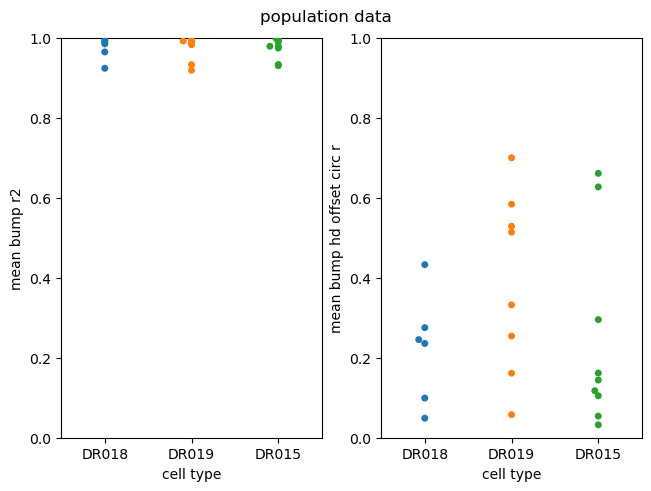

In [20]:
import seaborn as sns

category = 'cell_type'
stats = ['mean_bump_r2', 'mean_bump_hd_offset_circ_r']

fig, ax = plt.subplots(1, 2,
                       layout='constrained')
for index, stat in enumerate(stats):

    sns.swarmplot(data=processed_expt_df, x=category, y=stat,
                  ax=ax[index])
    ax[index].set_ylim([0,1])
    ax[index].set_xlabel(" ".join(category.split('_')))
    ax[index].set_ylabel(" ".join(stat.split('_')))

fig.suptitle("population data")

# Save plot
for fmt in PLOT_FORMATS:
    fig.savefig(Path(OUTPUT_FOLDER, "population_data" + fmt), dpi=600)

# Save raw stats
processed_expt_df.to_csv(Path(OUTPUT_FOLDER, "population_data.csv"))

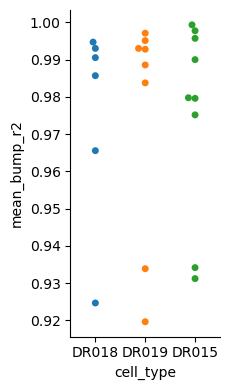

In [21]:
g = sns.catplot(
    data=processed_expt_df, x="cell_type", y='mean_bump_r2',
    kind="swarm", height=4, aspect=.6,
)


### Plot Each trial individually

In [22]:
OUTPUT_FOLDER = Path(r"Z:\GULP\results\bump_profile\individual_trials")
OUTPUT_FOLDER.mkdir(exist_ok=True, parents=True)

PLOT_FORMATS = [".png", ".svg"]

In [23]:
CELL_TYPES = ["DR015", "DR018", "DR019"]

GENETIC_TOOLS = ["iGluSnFR"]

In [24]:
processed_expt_df = expt_df[expt_df['proc_trial_count'] > 0]
processed_expt_df['expt'] = processed_expt_df['trials'].apply(Experiment)

# Remove empty experiments:
empty_expt_idxs = []
for idx, expt in processed_expt_df['expt'].items():
    if expt.synced_df is None:
        empty_expt_idxs.append(idx)
processed_expt_df = processed_expt_df.drop(index=empty_expt_idxs)

2024-07-29 16:59:28,268 - INFO - gulp2p.preproc.experiment - [experiment.py filter_trials() 46] - Trial 20240116_DR018xiGluSnFr_Fly1_00001 is missing synced_df, removing from Experiment.
2024-07-29 16:59:28,275 - INFO - gulp2p.preproc.experiment - [experiment.py filter_trials() 46] - Trial 20240117_DR019xiGluSnFr_Fly2_00004 is missing synced_df, removing from Experiment.
2024-07-29 16:59:28,309 - INFO - gulp2p.preproc.experiment - [experiment.py filter_trials() 46] - Trial 20240626_DR015xiGluSnfR_fly2_00002 is missing synced_df, removing from Experiment.
C:\Users\ahshenas\AppData\Local\Temp\ipykernel_520\2055239172.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  processed_expt_df['expt'] = processed_expt_df['trials'].apply(Experiment)


In [25]:
# Plot Individual trials
for index, expt_df_row in processed_expt_df.iterrows():
    expt = expt_df_row['expt']

    output_dir = Path(OUTPUT_FOLDER, expt_df_row['expt_name'])
    output_dir.mkdir(exist_ok=True, parents=True)

    for trial in expt.trials:
        trial_expt = Experiment(trials=[trial])
        logger.info(f"Plotting trial {trial_expt.trials[0].name}")
        fig, axd = plotting.plot_expt(trial_expt)
        trial_metadata = tr.parse_trial_name(trial.path, CELL_TYPES, GENETIC_TOOLS)
        fig_title = f"{trial_metadata['date']}_{trial_metadata['line']}_Fly{trial_metadata['fly']}_Trial{trial_metadata['trial']}"
        # print(fig_title)
        fig.suptitle(fig_title)
        for fmt in PLOT_FORMATS:
            fig.savefig(Path(output_dir, fig_title + fmt), dpi=600)
        plt.close(fig)

2024-07-29 16:59:28,341 - INFO - __main__ - [1018431775.py <module>() 10] - Plotting trial 20231206_DR018xiGluSnFr_Fly1_00001
2024-07-29 16:59:30,482 - INFO - __main__ - [1018431775.py <module>() 10] - Plotting trial 20231206_DR018xiGluSnFr_Fly1_00002
2024-07-29 16:59:32,507 - INFO - __main__ - [1018431775.py <module>() 10] - Plotting trial 20231206_DR018xiGluSnFr_Fly1_00003
2024-07-29 16:59:34,618 - INFO - __main__ - [1018431775.py <module>() 10] - Plotting trial 20231206_DR018xiGluSnFr_Fly1_00004
2024-07-29 16:59:37,211 - INFO - __main__ - [1018431775.py <module>() 10] - Plotting trial 20231206_DR018xiGluSnFr_Fly1_00005
2024-07-29 16:59:39,322 - INFO - __main__ - [1018431775.py <module>() 10] - Plotting trial 20231206_DR018xiGluSnFr_Fly1_00006
2024-07-29 16:59:41,325 - INFO - __main__ - [1018431775.py <module>() 10] - Plotting trial 20231206_DR018xiGluSnFr_Fly1_00007
2024-07-29 16:59:43,350 - INFO - __main__ - [1018431775.py <module>() 10] - Plotting trial 20231206_DR018xiGluSnFr_Fly

refiltering circular means with r >= 0.16035574242272388


2024-07-29 17:00:42,733 - INFO - __main__ - [1018431775.py <module>() 10] - Plotting trial 20231212_DR018xiGluSnFr_Fly2_00004
2024-07-29 17:00:44,961 - INFO - __main__ - [1018431775.py <module>() 10] - Plotting trial 20231214_DR015xiGluSnFr_Fly2_00001
2024-07-29 17:00:47,199 - INFO - __main__ - [1018431775.py <module>() 10] - Plotting trial 20231214_DR015xiGluSnFr_Fly2_00002
2024-07-29 17:00:49,365 - INFO - __main__ - [1018431775.py <module>() 10] - Plotting trial 20231214_DR015xiGluSnFr_Fly2_00003
2024-07-29 17:00:51,508 - INFO - __main__ - [1018431775.py <module>() 10] - Plotting trial 20231214_DR015xiGluSnFr_Fly2_00005
2024-07-29 17:00:53,660 - INFO - __main__ - [1018431775.py <module>() 10] - Plotting trial 20231214_DR015xiGluSnFr_Fly2_00007
2024-07-29 17:00:56,127 - INFO - __main__ - [1018431775.py <module>() 10] - Plotting trial 20231219_DR019xiGluSnFr_Fly1_00001
2024-07-29 17:00:58,148 - INFO - __main__ - [1018431775.py <module>() 10] - Plotting trial 20231219_DR019xiGluSnFr_Fly

In [26]:
## Plot PB with ROI's
for index, expt_df_row in processed_expt_df.iterrows():
    expt = expt_df_row['expt']

    output_dir = Path(OUTPUT_FOLDER, expt_df_row['expt_name'])
    output_dir.mkdir(exist_ok=True, parents=True)

    for trial in expt.trials:
        fig, ax = plt.subplots(figsize=(5,10), layout="constrained")
        plotting.plot_roi(expt.trials[0], ax)
        ax.set_title("")
        trial_metadata = tr.parse_trial_name(trial.path, CELL_TYPES, GENETIC_TOOLS)
        fig_title = f"{trial_metadata['date']}_{trial_metadata['line']}_Fly{trial_metadata['fly']}_Trial{trial_metadata['trial']}_PB_with_rois"
        for fmt in PLOT_FORMATS:
            fig.savefig(Path(output_dir, fig_title + fmt), dpi=600)
        plt.close(fig)

In [27]:
expt_df[expt_df['cell_type'] == 'DR015']

,expt_name,trial_paths,date,line,cell_type,genetic_tool,fly,trials,proc_trial_count
16,20231214_DR015xiGluSnFr_Fly1,[Z:\2PImaging\Kerstin\MIMS\20231214\20231214_D...,20231214,DR015xiGluSnFr,DR015,iGluSnFR,1,[],0
17,20231214_DR015xiGluSnFr_Fly2,[Z:\2PImaging\Kerstin\MIMS\20231214\20231214_D...,20231214,DR015xiGluSnFr,DR015,iGluSnFR,2,[<gulp2p.preproc.trial.Trial object at 0x00000...,5
22,20240118_DR015xiGluSnFr_Fly1,[Z:\2PImaging\Kerstin\MIMS\20240118\20240118_D...,20240118,DR015xiGluSnFr,DR015,iGluSnFR,1,[],0
23,20240118_DR015xiGluSnFr_Fly2,[Z:\2PImaging\Kerstin\MIMS\20240118\20240118_D...,20240118,DR015xiGluSnFr,DR015,iGluSnFR,2,[<gulp2p.preproc.trial.Trial object at 0x00000...,5
33,20240618_DR015xiGluSNfR_Fly1,[Z:\2PImaging\Kerstin\MIMS\20240618\20240618_D...,20240618,DR015xiGluSNfR,DR015,iGluSnFR,1,[<gulp2p.preproc.trial.Trial object at 0x00000...,7
34,20240620_DRo15xiGluSnFR_Fly2,[Z:\2PImaging\Kerstin\MIMS\20240620\20240620_D...,20240620,DRo15xiGluSnFR,DR015,iGluSnFR,2,[<gulp2p.preproc.trial.Trial object at 0x00000...,8
35,20240626_DR015xiGluSnfR_Fly1,[Z:\2PImaging\Kerstin\MIMS\20240626\20240626_D...,20240626,DR015xiGluSnfR,DR015,iGluSnFR,1,[<gulp2p.preproc.trial.Trial object at 0x00000...,2
36,20240626_DR015xiGluSnfR_Fly2,[Z:\2PImaging\Kerstin\MIMS\20240626\20240626_D...,20240626,DR015xiGluSnfR,DR015,iGluSnFR,2,[<gulp2p.preproc.trial.Trial object at 0x00000...,5
37,20240702_DR015xiGluSnfR_Fly1,[Z:\2PImaging\Kerstin\MIMS\20240702\20240702_D...,20240702,DR015xiGluSnfR,DR015,iGluSnFR,1,[<gulp2p.preproc.trial.Trial object at 0x00000...,14
38,20240708_DR015xiGluSnfR_Fly1,[Z:\2PImaging\Kerstin\MIMS\20240708\DR015xiGlu...,20240708,DR015xiGluSnfR,DR015,iGluSnFR,1,[<gulp2p.preproc.trial.Trial object at 0x00000...,3


### Examine 20240125_DR019xiGluSnFR_Fly02_00005 more closely

In [28]:
OUTPUT_FOLDER = Path(r"Z:\GULP\results\bump_profile")
OUTPUT_FOLDER.mkdir(exist_ok=True, parents=True)

PLOT_FORMATS = [".png", ".svg"]

In [29]:
# tiff_path = Path(r"Z:\2PImaging\Kerstin\MIMS\20240708\DR015xiGluSnfR_fly2_00001.tif")
root_tiff_folder = Path(r"Z:\2PImaging\Kerstin\MIMS\20231212")

In [30]:
trial_df = tr.create_trial_df(root_tiff_folder, CELL_TYPES, GENETIC_TOOLS)

In [31]:
trial_df

,path,date,line,cell_type,genetic_tool,fly,trial
0,Z:\2PImaging\Kerstin\MIMS\20231212\20231212_DR...,20231212,DR018xiGluSnFr,DR018,iGluSnFR,1,1
1,Z:\2PImaging\Kerstin\MIMS\20231212\20231212_DR...,20231212,DR018xiGluSnFr,DR018,iGluSnFR,1,2
2,Z:\2PImaging\Kerstin\MIMS\20231212\20231212_DR...,20231212,DR018xiGluSnFr,DR018,iGluSnFR,1,3
3,Z:\2PImaging\Kerstin\MIMS\20231212\20231212_DR...,20231212,DR018xiGluSnFr,DR018,iGluSnFR,1,4
4,Z:\2PImaging\Kerstin\MIMS\20231212\20231212_DR...,20231212,DR018xiGluSnFr,DR018,iGluSnFR,1,5
5,Z:\2PImaging\Kerstin\MIMS\20231212\20231212_DR...,20231212,DR018xiGluSnFr,DR018,iGluSnFR,1,6
6,Z:\2PImaging\Kerstin\MIMS\20231212\20231212_DR...,20231212,DR018xiGluSnFr,DR018,iGluSnFR,1,7
7,Z:\2PImaging\Kerstin\MIMS\20231212\20231212_DR...,20231212,DR018xiGluSnFr,DR018,iGluSnFR,1,8
8,Z:\2PImaging\Kerstin\MIMS\20231212\20231212_DR...,20231212,DR018xiGluSnFr,DR018,iGluSnFR,1,9
9,Z:\2PImaging\Kerstin\MIMS\20231212\20231212_DR...,20231212,DR018xiGluSnFr,DR018,iGluSnFR,1,10


In [32]:
trial_df = trial_df[(trial_df['fly']==2) & (trial_df['trial']==3)]

In [33]:
expt_df = create_expt_df(trial_df, CELL_TYPES, GENETIC_TOOLS)

In [34]:
expt_df

,expt_name,trial_paths,date,line,cell_type,genetic_tool,fly,trials,proc_trial_count
0,20231212_DR018xiGluSnFr_Fly2,[Z:\2PImaging\Kerstin\MIMS\20231212\20231212_D...,20231212,DR018xiGluSnFr,DR018,iGluSnFR,2,[<gulp2p.preproc.trial.Trial object at 0x00000...,1


In [35]:
processed_expt_df = expt_df[expt_df['proc_trial_count'] > 0]
processed_expt_df['expt'] = processed_expt_df['trials'].apply(Experiment)

In [36]:
# def filter_mean_rois(mean_rois, circ_rs, min_r=0.15):
#     # in place change
#     if np.issubdtype(mean_rois.dtype, np.integer):
#         empty_value = -1
#     else:
#         empty_value = np.nan

#     filtered_mean_rois = np.copy(mean_rois)

#     mask = (circ_rs <  min_r)
#     filtered_mean_rois[mask] = empty_value
#     if np.isnan(filtered_mean_rois).all():
#         logger.warning(f"No circular mean found with r >= {min_r}")
#     return filtered_mean_rois



# bump_region = "mean"

# upper_deltaf = np.array(expt.synced_df.iloc[:, expt.rois_per_arm:expt.num_rois])
# lower_deltaf = np.array(expt.synced_df.iloc[:, 0:expt.rois_per_arm])

# if bump_region == "upper":
#     deltaf = upper_deltaf
# if bump_region == "lower":
#     deltaf = lower_deltaf
# if bump_region == "mean":
#     deltaf = np.mean(np.array([upper_deltaf, lower_deltaf]), axis=0)

# mean_rois = plotting.get_mean_rois(deltaf, precise=True)
# circ_rs = plotting.get_circ_rs(deltaf)
# filtered_mean_rois = filter_mean_rois(mean_rois, circ_rs, min_r=0.3)
# # Check if filter_mean_rois filtered out all points
# if np.isnan(filtered_mean_rois).all():
#     min_r = np.quantile(circ_rs, 1-0.1)
#     print(f"refiltering circular means with r >= {min_r}")
#     filtered_mean_rois = filter_mean_rois(mean_rois, circ_rs, min_r=min_r)


# int_head_direction = ((filtered_mean_rois * 360 / 8)) % 360
# ext_head_direction = (expt.synced_df.angle) % 360

# hd_offset = (int_head_direction - ext_head_direction) % 360

# print(f"filtered_mean_rois all nan: {np.isnan(filtered_mean_rois).all()}")
# print(f"int_head_direction all nan: {np.isnan(int_head_direction).all()}")
# print(f"ext_head_direction all nan: {np.isnan(ext_head_direction).all()}")

In [37]:
np.quantile(circ_rs, 0.9)

0.3078208732327204

In [38]:
# imaging.process_all(tiff_paths, save=True, skip=False, use_full_volume=False)

In [39]:
# expt.synced_df.columns

2024-07-29 17:16:18,496 - WARNING - gulp2p.viz.plotting - [plotting.py filter_mean_rois() 187] - No circular mean found with r >= 0.3


refiltering circular means with r >= 0.16035574242272388


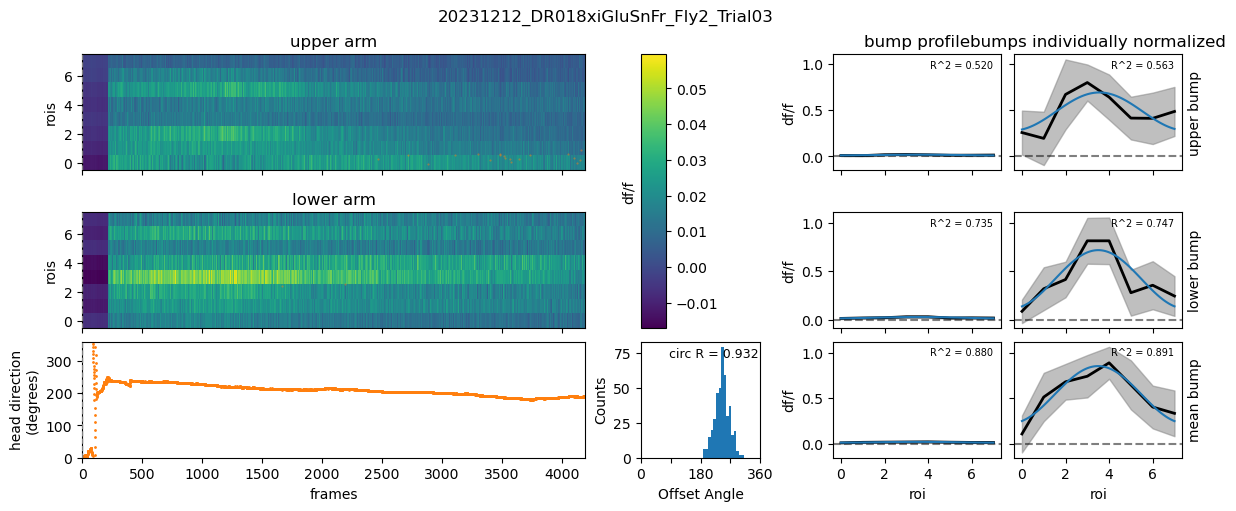

In [40]:

for index, expt_df_row in processed_expt_df.iterrows():
    # Plot experiment
    expt = expt_df_row['expt']

    fig, axd = plotting.plot_expt(expt)

    fig_title = expt_df_row['expt_name'] + f"_Trial{expt.trials[0].name[-2:]}"
    fig.suptitle(fig_title)
    for fmt in PLOT_FORMATS:
        fig.savefig(Path(OUTPUT_FOLDER, fig_title + fmt), dpi=600)

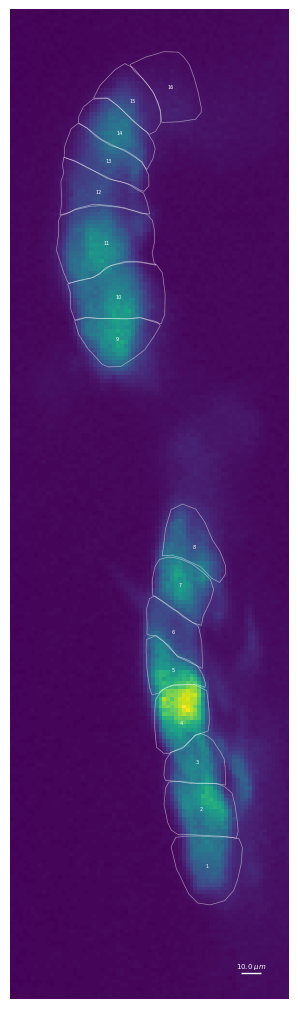

In [41]:
fig, ax = plt.subplots(figsize=(5,10), layout="constrained")
plotting.plot_roi(expt.trials[0], ax)
ax.set_title("")
for fmt in PLOT_FORMATS:
    fig.savefig(Path(OUTPUT_FOLDER, fig_title + "PB_with_rois" + fmt), dpi=600)

In [42]:
# plot offset of ext and int hd
# Plot circ var of offset

upper_deltaf = expt.synced_df.iloc[:, expt.rois_per_arm:expt.num_rois]
lower_deltaf = expt.synced_df.iloc[:, 0:expt.rois_per_arm]

mean_rois = plotting.get_mean_rois(upper_deltaf, precise=True)
circ_rs = plotting.get_circ_rs(upper_deltaf)
filtered_mean_rois = plotting.filter_mean_rois(mean_rois, circ_rs, min_r=0.3)

int_visual_shift = -120
int_head_direction = ((mean_rois * 360 / 8) + int_visual_shift) % 360

In [43]:
ext_visual_shift = 180
ext_head_direction = (expt.synced_df.angle * 1 + ext_visual_shift) % 360

In [44]:
offset_visual_shift = 180
hd_offset =  (int_head_direction - ext_head_direction + offset_visual_shift) % 360

In [45]:
Y_pred = hd_offset
Y_true = np.full(hd_offset.shape, hd_offset.mean())
offset_mse = np.square(np.subtract(Y_true,Y_pred)).mean() 

Text(0.99, 0.95, 'circ R = 0.839')

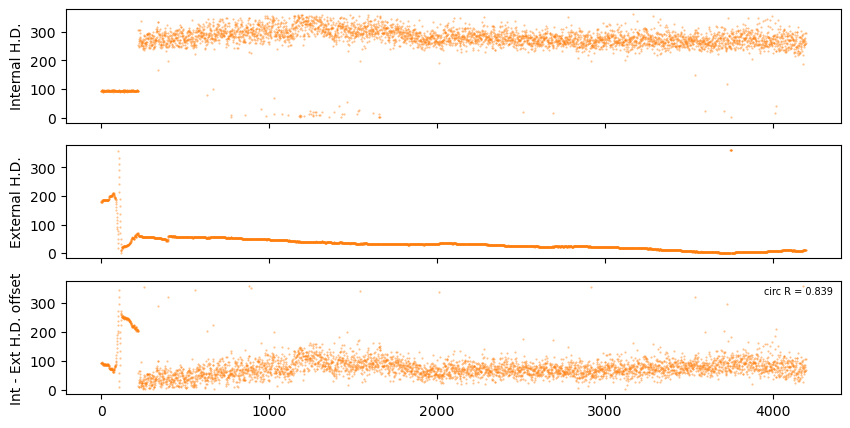

In [46]:
fig, axs = plt.subplots(3, figsize=(10,5), sharex=True)
axs[0].plot(int_head_direction, marker='o', linestyle="", ms=0.5, color="C1", alpha=0.5)
axs[0].set_ylabel("Internal H.D.")
axs[1].plot(ext_head_direction, marker='o', linestyle="", ms=0.5, color="C1", alpha=0.5)
axs[1].set_ylabel("External H.D.")
axs[2].plot(hd_offset, marker='o', linestyle="", ms=0.5, color="C1", alpha=0.5)
axs[2].set_ylabel("Int - Ext H.D. offset")

# axs[0].set_xlim(5000, 10000)

circ_r = pingouin.circ_r(pingouin.convert_angles(hd_offset))
metric = f"circ R = {circ_r:.3f}"
axs[2].text(0.99, 0.95, metric, fontsize=7,
        transform=axs[2].transAxes, ha='right', va='top')